# Chapter 25: The Continuous Learning System

**How much of the noise behind a logged gain does averaging more fold seeds remove, and what does a seed-based threshold then keep?**

The chapter says a negative result is local evidence, that a retrieval note must be checked against a real decision, and that counting notes is not evidence the system helped. A note's gain has noise from the fold seed and from the finite sample; measuring both shows how far a seed check goes.

*Constructed data. The effect, the number of candidates and the learner set the sizes; the direction (seeds shrink their own noise, not the sample's, and kept gains overstate) is the claim.*

## The experiment

Thirty-two constructed competitions of 1,200 rows with 10 baseline features and 16 candidate features: 5 carry a small true effect and 11 are pure noise. Each candidate's gain is the paired difference in 5-fold cross-validated AUC between baseline plus candidate and the baseline, with a ridge-regularized linear model as the learner, repeated over 10 fold seeds. A note averages the first s seeds (the control). Truth is each candidate's gain on 20,000 new rows. Two rules decide whether a note is kept: any positive gain, and a gain above twice the fold-seed standard error.

In [1]:
import numpy as np
from scipy.stats import rankdata

from kaggle_companion.activities._common import clean

SEED = 25
CAMPAIGNS = 32        # independent constructed competitions; each logs notes for 16 candidate features
N_ROWS, BASE_FEATURES, CANDIDATES, REAL = 1200, 10, 16, 5   # 5 candidates carry a small true effect, 11 are pure noise
EFFECT = 0.15         # true coefficient (log odds per standard deviation) of a real candidate
SEEDS = 10            # fold seeds tried for every candidate; a note with s seeds averages the first s
FRESH_ROWS = 20000    # new rows from the same generator: each candidate's true gain
RIDGE = 10.0


def auc(y, score):
    ranks = rankdata(score)
    positives = y.sum()
    return (ranks[y == 1].sum() - positives * (positives + 1) / 2) / (positives * (len(y) - positives))


def fit_ridge(X, target):
    """Closed-form ridge regression on -1/+1 labels: a fast linear stand-in for a gradient-boosted baseline."""
    A = np.column_stack([np.ones(len(X)), X])
    penalty = RIDGE * np.eye(A.shape[1])
    penalty[0, 0] = 0
    return np.linalg.solve(A.T @ A + penalty, A.T @ target)


def predict(w, X):
    return w[0] + X @ w[1:]


def cv_auc(X, y, fold_seed):
    """Pooled out-of-fold AUC of 5-fold cross-validation with this fold seed."""
    folds = np.array_split(np.random.default_rng(1000 + fold_seed).permutation(len(y)), 5)
    target, score = 2.0 * y - 1, np.zeros(len(y))
    for val in folds:
        fit_rows = np.ones(len(y), bool)
        fit_rows[val] = False
        score[val] = predict(fit_ridge(X[fit_rows], target[fit_rows]), X[val])
    return auc(y, score)


def one_campaign(seed):
    """One competition: a fixed set of rows, a baseline, and 16 candidate features. Returns each candidate's per-seed gains and true gain."""
    rng = np.random.default_rng(seed)
    base_weights = rng.normal(0, 0.45, BASE_FEATURES)
    beta = np.r_[np.full(REAL, EFFECT), np.zeros(CANDIDATES - REAL)]

    def rows(n):
        X, F = rng.normal(size=(n, BASE_FEATURES)), rng.normal(size=(n, CANDIDATES))
        logit = X @ base_weights + F @ beta - 0.1
        return X, F, (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    (X, F, y), (X_new, F_new, y_new) = rows(N_ROWS), rows(FRESH_ROWS)
    base = np.array([cv_auc(X, y, s) for s in range(SEEDS)])
    base_new = auc(y_new, predict(fit_ridge(X, 2.0 * y - 1), X_new))
    out = []
    for j in range(CANDIDATES):
        augmented = np.column_stack([X, F[:, j]])
        gains = np.array([cv_auc(augmented, y, s) for s in range(SEEDS)]) - base         # paired: same folds, same rows
        true = auc(y_new, predict(fit_ridge(augmented, 2.0 * y - 1), np.column_stack([X_new, F_new[:, j]]))) - base_new
        out.append((j < REAL, gains, true))
    return out


def run(seeds_averaged):
    items = [c for i in range(CAMPAIGNS) for c in one_campaign(SEED * 1000 + i)]
    seed_sd = float(np.mean([gains.std(ddof=1) for _, gains, _ in items]))           # spread of one candidate's gain across fold seeds
    logged = np.array([gains[:seeds_averaged].mean() for _, gains, _ in items])      # the number written in the note
    real = np.array([r for r, _, _ in items])
    true = np.array([t for _, _, t in items])
    seed_se = seed_sd / np.sqrt(seeds_averaged)
    rules = {}
    for name, bar in (("any_positive", 0.0), ("seed_floor", 2 * seed_se)):
        kept = logged > bar
        rules[name] = {"bar": bar, "keeps_real": float(kept[real].mean()), "keeps_noise": float(kept[~real].mean()),
                       "precision": float(real[kept].mean()), "logged_of_kept": float(logged[kept].mean()), "true_of_kept": float(true[kept].mean())}
    return clean({
        "seeds_averaged": seeds_averaged, "candidates": len(items), "noise_candidates": int((~real).sum()), "campaigns": CAMPAIGNS,
        "seed_sd": seed_sd, "seed_se": seed_se, "noise_spread": float(logged[~real].std()),
        "true_gain_real": float(true[real].mean()), "true_gain_noise": float(true[~real].mean()),
        "logged_gain_real": float(logged[real].mean()), "rules": rules,
    }, digits=6)   # the gains are a few ten-thousandths of AUC: keep enough digits for the ratios shown


## Measure it across the control

The control is **fold seeds averaged in each logged note**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch25 import explain

VALUES = [1, 3, 10]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                             1        3       10
Seed standard error of a note          0.00066  0.00038  0.00021
Spread of noise features' gains        0.00101  0.00081  0.00075
Seed floor (2 SE)                      0.00132  0.00076  0.00042
Noise features kept by the seed floor    0.043    0.057    0.091
Real features kept by the seed floor     0.512    0.613    0.688


## Look at it

The figure shows the default setting, fold seeds averaged in each logged note = 10.

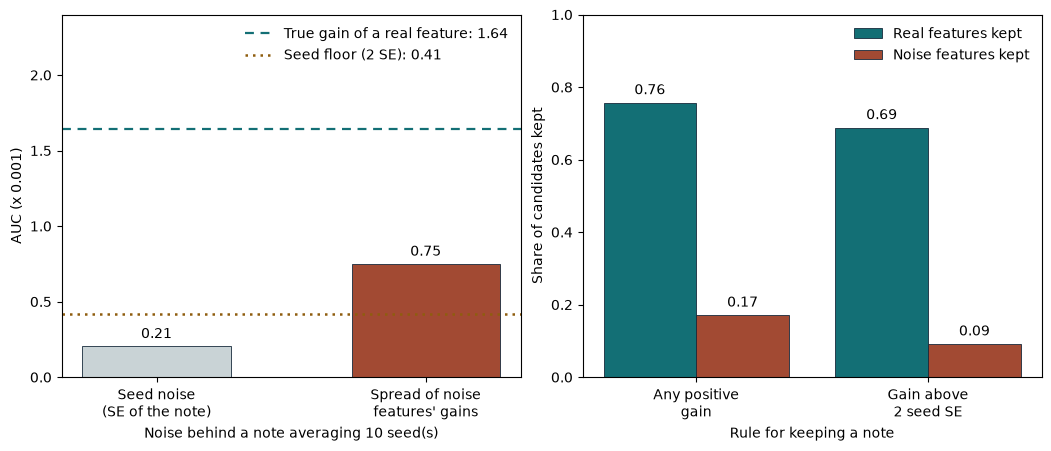

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch25 import draw, NCOLS, HEIGHT

DEFAULT = 10
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

A note averaging 10 seed(s) has a seed standard error of 0.00021, so the seed floor is 2 x 0.00021 = 0.00042. Across 352 pure-noise features the logged gains still spread by 0.00075, 3.6 times the seed error. The seed-floor rule keeps 0.091 of noise features and 0.688 of real ones; any positive gain keeps 0.170 of noise features. Kept notes log 0.00240 on average against a true 0.00094: 0.00240 - 0.00094 = 0.00146 of overstatement.

- Seed standard deviation of one run: 0.00066; with 10 seed(s) the standard error is 0.00021.
- Spread of the noise features' logged gains: 0.00075 (seed error 0.00021).
- Seed-floor rule: keeps 0.688 of real and 0.091 of noise features; precision 0.77.
- Kept notes: logged 0.00240 - true 0.00094 = 0.00146.

## Apply this to your competition

- Fix and store the fold seeds and fold IDs with each note, so the number can be regenerated, as the chapter's reproduction checks require.
- Estimate the noise floor from pure-noise candidates (shuffled or random columns) run through the same pipeline, not only from re-seeding the folds.
- Expect a kept note's gain to overstate the true gain; confirm any note you will build on with fresh rows or a second, independent campaign.
- Record negative and null results with the same care: a near-zero gain inside the noise is information about the noise, not a permanent ban.

Book location: Chapter 25, Preserve Failures and Reproduction Conditions.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)